# COMP47950 Quantum Machine Learning

## Gerard Carrigan

## 18331341

## Classical vs Quantum ML Project

### Dataset: *Would I Lie To You (WILTY)* comedy series records

This notebook goes through the **classical machine learning baseline** for the WILTY prediction task.

The goal is to predict whether the opposing team will correctly judge a statement as truth or lie using historical game play behaviour as features.

The results from the classical approach will be used as the benchmark when comparing against the quantum modelling approaches later on. 5 of the 9 features will be used in the encoding of the quantum models.

### Notebook sections:

1. Environment setup
2. Load WILTY dataset
3. EDA
4. Feature Engineering
5. Feature summary and Analysis
6. Temporal Train/Test split
7. Preprocessing
8. Classical Model selection
9. Results comparison
10. Feature Importance Analysis
11. Discussion
12. Prep for QML section of project

## 1. Environment Setup

In [105]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import pickle
import json
import time
import warnings
import os
warnings.filterwarnings('ignore')

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# classical ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import prince

# QML 
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.optimizers import COBYLA, SPSA
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import BackendSamplerV2

print("Classical/QML env ready. Imports successful..!")

Classical/QML env ready. Imports successful..!


## Seeds for reproducibility

In [3]:
SEED = 42
np.random.seed(SEED)
algorithm_globals.random_seed = SEED # qiskit VQC initial weights and optimisers

## 2. Load WILTY Dataset (seasons.csv)

In [ ]:
df = pd.read_csv('seasons.csv')
df.columns = [c.lower() for c in df.columns] # lower case columns names

print(f"Dataset shape: {df.shape}")


Dataset shape: (765, 12)
Seasons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Episodes per season: {1: 6, 2: 8, 3: 8, 4: 8, 5: 8, 6: 8, 7: 9, 8: 9, 9: 9, 10: 9, 11: 9, 12: 9, 13: 10, 14: 10, 15: 10, 16: 10}


## 3. Exploratory Data Analysis

View the dataset to understand the different columns / season / episode count and check for missing values.

In [8]:
df.head()

,season,episode,defender,captain,opp1,opp2,opp3,verdictteam,verdict1,verdict2,verdict3,veracity
0,1,1,Dom Joly,Lee Mack,David Mitchell,Duncan Bannatyne,Frankie Boyle,False,False,True,True,True
1,1,1,Duncan Bannatyne,David Mitchell,Lee Mack,Natalie Cassidy,Dom Joly,True,True,True,True,True
2,1,1,Natalie Cassidy,Lee Mack,David Mitchell,Duncan Bannatyne,Frankie Boyle,True,True,True,True,False
3,1,1,Lee Mack,Lee Mack,David Mitchell,Duncan Bannatyne,Frankie Boyle,True,True,True,False,False
4,1,1,David Mitchell,David Mitchell,Lee Mack,Natalie Cassidy,Dom Joly,True,True,True,True,True


In [9]:
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Episodes per season: {df.groupby('season')['episode'].nunique().to_dict()}")
print(f"Max number of episodes in a season: {df.groupby('season')['episode'].nunique().max()}")

Seasons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Episodes per season: {1: 6, 2: 8, 3: 8, 4: 8, 5: 8, 6: 8, 7: 9, 8: 9, 9: 9, 10: 9, 11: 9, 12: 9, 13: 10, 14: 10, 15: 10, 16: 10}
Max number of episodes in a season: 10


In [10]:
print(f"Column data types:\n{df.dtypes}")

Column data types:
season         int64
episode        int64
defender         str
captain          str
opp1             str
opp2             str
opp3             str
verdictteam     bool
verdict1        bool
verdict2        bool
verdict3        bool
veracity        bool
dtype: object


In [14]:
captains = df["captain"].unique()

print("Number of statements:", len(df))
print("\nNumber of captains over the 16 seasons:", len(captains))
for captain in captains:
    print(captain)

Number of statements: 765

Number of captains over the 16 seasons: 2
Lee Mack
David Mitchell


In [11]:
# sort seasons in chronological order
df = df.sort_values(['season', 'episode']).reset_index(drop=True)
df['show_index'] = df.index

## Number of statements per season

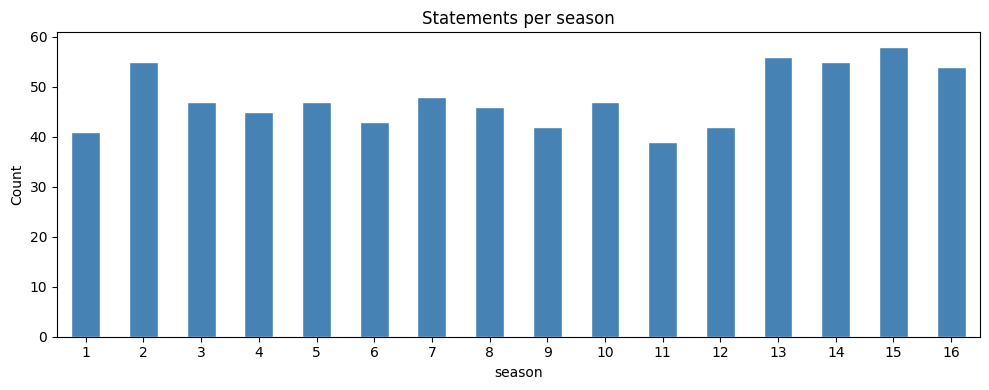

In [13]:
# statements per season
df.groupby('season').size().plot(kind='bar', color='steelblue', edgecolor='white', figsize=(10, 4))
plt.title('Statements per season')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Guest appearance frequency

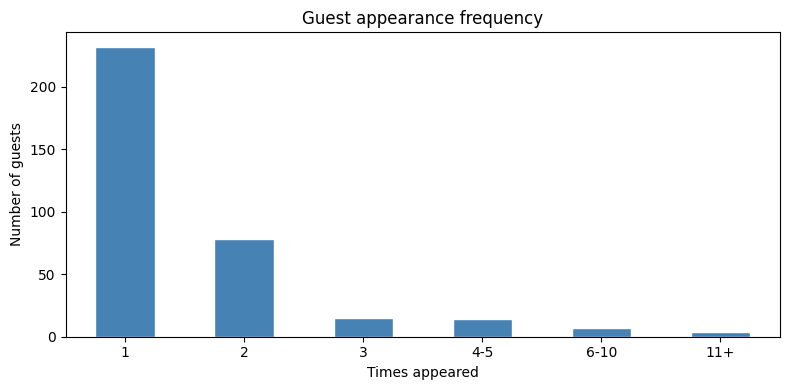

Unique defenders: 352
Appear once: 232 (65.9%)
Appear 4+ times: 27


In [15]:
count_of_appearances = df['defender'].value_counts()
bins = [0, 1, 2, 3, 5, 10, 20]
labels = ['1', '2', '3', '4-5', '6-10', '11+']
pd.cut(count_of_appearances, bins=bins, labels=labels).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white', figsize=(8, 4))
plt.title('Guest appearance frequency')
plt.ylabel('Number of guests')
plt.xlabel('Times appeared')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Unique defenders: {df['defender'].nunique()}")
print(f"Appear once: {(count_of_appearances == 1).sum()} ({(count_of_appearances == 1).mean():.1%})")
print(f"Appear 4+ times: {(count_of_appearances >= 4).sum()}")

## Distriubtion of true / false statements

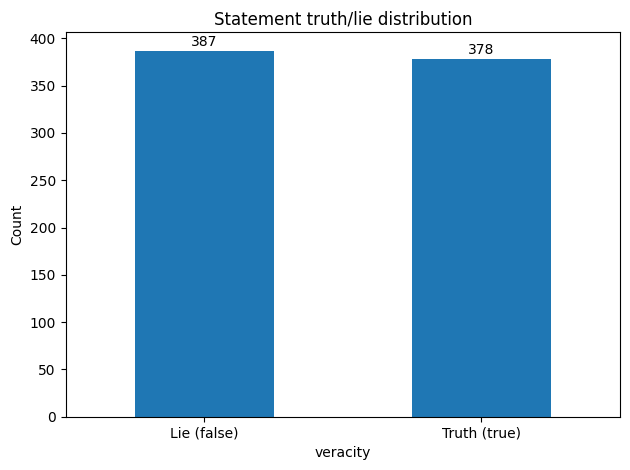

In [18]:
ax = df['veracity'].value_counts().plot(kind='bar')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 5, int(p.get_height()), ha='center')
plt.title('Statement truth/lie distribution')
plt.xticks(ticks=[0, 1], labels=['Lie (false)', 'Truth (true)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3.1 Target Variable: correct_judgement

Predict whether a statement is correctly judged by the opposing team.

Given the historical skill of the speaker, the historical detection skill of the opposing team and the context of the episode, can we build a model that will predict whether this statement will be correctly judged?

1 = panel correctly identifies truth/lie  
0 = panel is fooled

This converts the problem into a binary classification task.

In [23]:
# target variable
df['correct_judgement'] = (df['verdictteam'] == df['veracity']).astype(int)

print("Overall class distribution:")
print(df['correct_judgement'].value_counts(normalize=True).rename({0: 'Fooled (0)', 1: 'Correct (1)'}))



Overall class distribution:
correct_judgement
Fooled (0)     0.60915
Correct (1)    0.39085
Name: proportion, dtype: float64


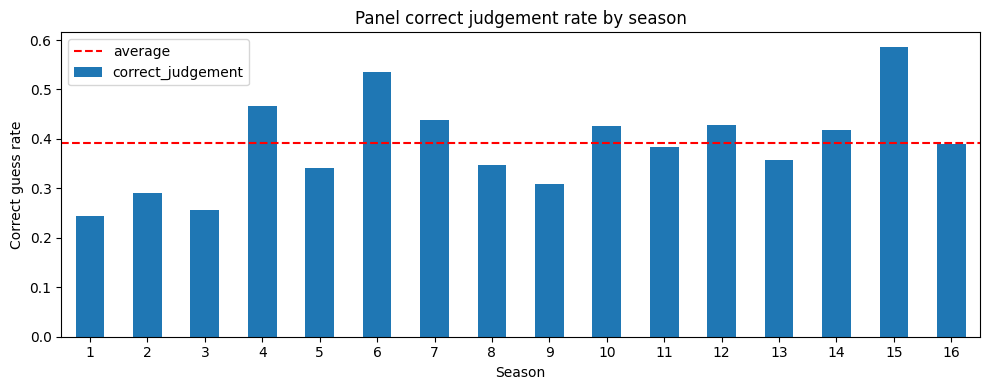

In [28]:
# correct_judgement rate broken down by season
season_correct_judgement_rates = df.groupby('season')['correct_judgement'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
season_correct_judgement_rates.plot(kind='bar', ax=ax)
ax.axhline(y=df['correct_judgement'].mean(), color='red', linestyle='--', label='average')
ax.set_title('Panel correct judgement rate by season')
ax.set_ylabel('Correct guess rate')
ax.set_xlabel('Season')
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Goal: Convert gameplay behaviour into numerical features.

**Historical stats:** computed from past rounds only, using .shift(1) to prevent leakage
- player_fool_rate
- opponent_avg_detection_rate
- skill_gap
- prior_appearances
- is_regular


**Round-level observations:** known at judgement time of the current round
- is_lie
- captain_team
- statement_index_normalsied
- unanimous_agreement

Given everything observable around a completed round, including whether the statement was a lie, can a model be built to accurately predict whether the panel got it right?


**Note on bias:** several of the features I chose to build (eg. player fool rate, opponent detection rate) encode assumptions about what I thought would be key to the panel achieving high correct judgement. A different feature eng approach would very likely yield much different results. These assumptions I have made / biases should be kept in mind when interpreting and comparing the results.

### Feature 1: Statement is a Lie Or Not

Binary encoding of whether the statement is actually a lie. This is known to the audience at prediction time. The show reveals veracity after the panel has guessed. Lies and truths may have different detection rates.



In [29]:
df['is_lie'] = (~df['veracity']).astype(int)

print("is_lie distribution:")
print(df['is_lie'].value_counts())

is_lie distribution:
is_lie
1    387
0    378
Name: count, dtype: int64


Below judgement rates indicate that the panels appear to have better judgement when the defender is telling the truth vs a lie

In [30]:
print(f"Correct judgement when lie: {df[df['is_lie']==1]['correct_judgement'].mean():.3f}")
print(f"Correct judgement when truth: {df[df['is_lie']==0]['correct_judgement'].mean():.3f}")

Correct judgement when lie: 0.261
Correct judgement when truth: 0.524


Confirmed no data leakage: is_lie is revealed by the host only after the panel has voted. The panel itself never sees it at decision time, the classification task here is retrospective, not real-time prediction.

The fact that the best model has 0.615 accuracy confirms is_lie is a strong but non deterministic signal. It is a legitimate post hoc feature for this retrospective task (Did the panel guess correctly?)


### Feature 2: Guest Prior appearances

How many times the defender (statement reader) has appeared on the show before this episode. Repeat guests may develop strategies that make them harder or easier to read.

In [32]:
df['prior_appearances'] = df.groupby('defender').cumcount()

print("Prior appearances distribution:")
print(df['prior_appearances'].describe())

Prior appearances distribution:
count    765.000000
mean       9.849673
std       20.057565
min        0.000000
25%        0.000000
50%        1.000000
75%        5.000000
max       89.000000
Name: prior_appearances, dtype: float64


### Feature 3: Guest is a Regular

Binary flag for guests who have appeared 3 or more times previously. It is assumed that this prior experience will help these guests in identifying truth/lie vs a newcomer to the show.

In [33]:
df['is_regular'] = (df['prior_appearances'] >= 3).astype(int)

print("Regular vs one-off:")
print(df['is_regular'].value_counts())

Regular vs one-off:
is_regular
0    514
1    251
Name: count, dtype: int64


### Feature 4: player_fool_rate

The defender's historical success rate at fooling the opposing team

In [39]:
df['fooled_team'] = 1 - df['correct_judgement']

df['player_fool_rate'] = (
    df.groupby('defender')['fooled_team']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

# neutral prior for first appearance 50/50 chance
df['player_fool_rate'] = df['player_fool_rate'].fillna(0.5)

print("player_fool_rate stats:")
print(df['player_fool_rate'].describe())

player_fool_rate stats:
count    765.000000
mean       0.596013
std        0.391001
min        0.000000
25%        0.250000
50%        0.666667
75%        1.000000
max        1.000000
Name: player_fool_rate, dtype: float64


### Feature 5: opponent_avg_detection_rate

The average historical detection skill of the three opposing team members.

Each opponent's detection rate is computed as their cumulative accuracy over the series.

This requires unpivoting the three opponent columns into a single judgement-level dataframe, computing per-judge rates, then merging back and averaging.

In [40]:
# individual judgements converted into long format
judgements = []
for i in [1, 2, 3]:
    temp = df[['show_index', 'season', 'episode', f'opp{i}', f'verdict{i}', 'veracity']].copy()
    temp.columns = ['show_index', 'season', 'episode', 'judge', 'verdict', 'veracity']
    judgements.append(temp)

# verdict == veracity
judgement_df = pd.concat(judgements, ignore_index=True)
judgement_df['correct'] = (judgement_df['verdict'] == judgement_df['veracity']).astype(int)

# calculate cumulative detection rate per team member
judgement_df = judgement_df.sort_values(['season', 'episode']).reset_index(drop=True)

judgement_df['player_detection_rate'] = (
    judgement_df.groupby('judge')['correct']
                .expanding()
                .mean()
                .shift(1)
                .reset_index(level=0, drop=True)
)

# 50/50 chance for first judgement
judgement_df['player_detection_rate'] = judgement_df['player_detection_rate'].fillna(0.5)

# merge  detection rates back
for i in [1, 2, 3]:
    df = df.merge(
        judgement_df[['show_index', 'judge', 'player_detection_rate']],
        left_on=['show_index', f'opp{i}'],
        right_on=['show_index', 'judge'],
        how='left'
    ).rename(columns={'player_detection_rate': f'opp{i}_detection_rate'}).drop(columns=['judge'])

# average of opp1/opp2/opp3 detection rates
df['opponent_avg_detection_rate'] = (
    df[['opp1_detection_rate', 'opp2_detection_rate', 'opp3_detection_rate']].mean(axis=1)
)

print(df['opponent_avg_detection_rate'].describe())

count    765.000000
mean       0.399129
std        0.192014
min        0.043478
25%        0.255319
50%        0.397312
75%        0.515816
max        1.000000
Name: opponent_avg_detection_rate, dtype: float64


### Feature 6: statement_index_normalised

Order of when statement was given during the show. Usually 6-7 statements per episode, normalised to [0, 1]. Earlier or later statements may be judged differently due to fatigue, warming up etc

In [41]:
df['statement_index'] = df.groupby(['season', 'episode']).cumcount() + 1
df['max_statements'] = df.groupby(['season', 'episode'])['statement_index'].transform('max')
df['statement_index_normalised'] = df['statement_index'] / df['max_statements']

print("statement_index_normalised stats:")
print(df['statement_index_normalised'].describe())

statement_index_normalised stats:
count    765.000000
mean       0.591503
std        0.284365
min        0.111111
25%        0.333333
50%        0.600000
75%        0.833333
max        1.000000
Name: statement_index_normalised, dtype: float64


### Feature 7: captain_team

Binary encoding of which team the defender belongs to. Lee Mack or David Mitchell

In [43]:
df['captain_team'] = (df['captain'] == 'Lee Mack').astype(int)  # 1 = Lee Mack's team, 0 = David Mitchell's team

print("Captain tean distribution:")
print(df['captain_team'].value_counts().rename({1: "Lee Mack's team", 0: "David Mitchell's team"}))
print(f"\nCorrect judgement by team:")
print(df.groupby('captain_team')['correct_judgement'].mean().rename({1: "Lee Mack's team", 0: "David Mitchell's team"}))

Captain tean distribution:
captain_team
Lee Mack's team          396
David Mitchell's team    369
Name: count, dtype: int64

Correct judgement by team:
captain_team
David Mitchell's team    0.422764
Lee Mack's team          0.361111
Name: correct_judgement, dtype: float64


### Feature 8: skill_gap

The difference between the defender's fool rate and the opposing team's average detection rate (non linear relationship). A positive skill gap means the defender is historically better at fooling than the opponents are at detecting, which "should" predict an incorrect panel judgement.

In [49]:
df['skill_gap'] = df['player_fool_rate'] - df['opponent_avg_detection_rate']

# print some stats
print(df['skill_gap'].describe())

count    765.000000
mean       0.196884
std        0.443244
min       -0.866667
25%       -0.163441
50%        0.228700
75%        0.557576
max        0.956522
Name: skill_gap, dtype: float64


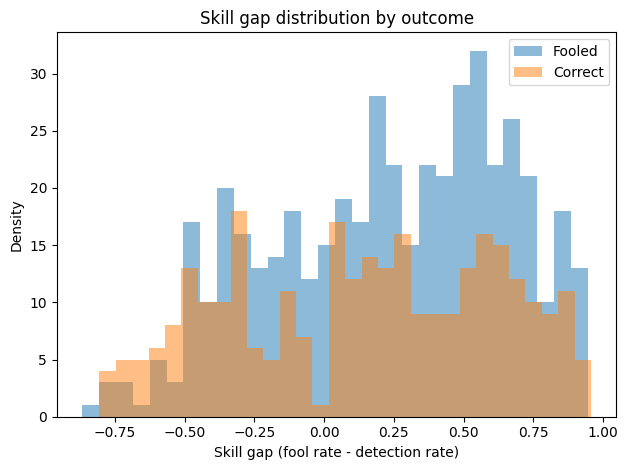

In [ ]:
df.groupby('correct_judgement')['skill_gap'].plot(kind='hist', bins=30, alpha=0.5)
plt.xlabel('Skill gap (fool rate - detection rate)')
plt.ylabel('Density')
plt.title('Skill gap distribution by outcome')
plt.legend(['Fooled', 'Correct'])
plt.tight_layout()
plt.show()

### Feature 9: unanimous_agreement

Binary flag to encode when the whole team and in agreement and vote the same way.

The feature does not reveal what the panel voted, only how confident their decision was.

In [50]:
# check if the whole team voted the same way
df['unanimous_agreement'] = (
    (df['verdict1']==df['verdict2']) & (df['verdict2']==df['verdict3'])
).astype(int)

In [54]:
print(df['unanimous_agreement'].value_counts().rename({0:'Split (0)', 1:'Unanimous (1)'}))
print(f"Correct judgement rate by agreement:")
print(df.groupby('unanimous_agreement')['correct_judgement'].agg(['mean', 'count']).rename(index={0: 'Split', 1: 'Unanimous'}))

unanimous_agreement
Unanimous (1)    526
Split (0)        239
Name: count, dtype: int64
Correct judgement rate by agreement:
                         mean  count
unanimous_agreement                 
Split                0.414226    239
Unanimous            0.380228    526


 Viewing the judgement rate by unanimous agreement: it looks like panels in full agreement are less accurate (38%) than split panels (41%)...this may indicate groupthink rather than a genuine detection skill

## 5. Summary of 9 features and analysis

In [55]:
features = [
    'is_lie',
    'prior_appearances',
    'is_regular',
    'player_fool_rate',
    'opponent_avg_detection_rate',
    'statement_index_normalised',
    'captain_team',
    'skill_gap',
    'unanimous_agreement'
]

print(f"Total features: {len(features)}")
print(f"\nFeature summary statistics:")
df[features].describe().round(4)

Total features: 9

Feature summary statistics:


,is_lie,prior_appearances,is_regular,player_fool_rate,opponent_avg_detection_rate,statement_index_normalised,captain_team,skill_gap,unanimous_agreement
count,765.0000,765.0000,765.0000,765.0000,765.0000,765.0000,765.0000,765.0000,765.0000
mean,0.5059,9.8497,0.3281,0.5960,0.3991,0.5915,0.5176,0.1969,0.6876
std,0.5003,20.0576,0.4698,0.3910,0.1920,0.2844,0.5000,0.4432,0.4638
min,0.0000,0.0000,0.0000,0.0000,0.0435,0.1111,0.0000,-0.8667,0.0000
25%,0.0000,0.0000,0.0000,0.2500,0.2553,0.3333,0.0000,-0.1634,0.0000
50%,1.0000,1.0000,0.0000,0.6667,0.3973,0.6000,1.0000,0.2287,1.0000
75%,1.0000,5.0000,1.0000,1.0000,0.5158,0.8333,1.0000,0.5576,1.0000
max,1.0000,89.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9565,1.0000


### Feature correlation matrix

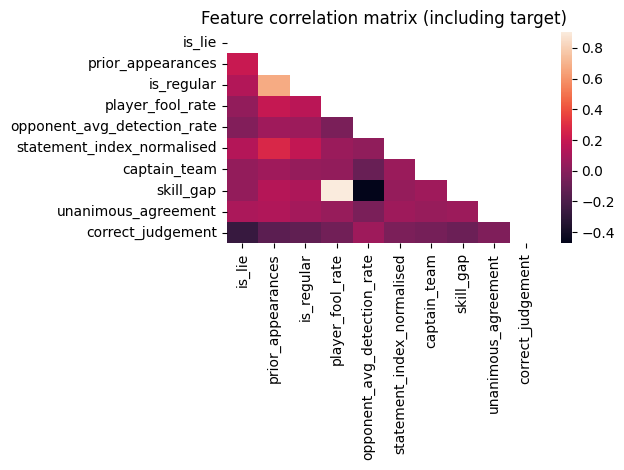


Correlation with target (correct_judgement):
opponent_avg_detection_rate    0.0664
unanimous_agreement           -0.0323
statement_index_normalised    -0.0425
captain_team                  -0.0631
player_fool_rate              -0.0741
skill_gap                     -0.0942
is_regular                    -0.1318
prior_appearances             -0.1478
is_lie                        -0.2693
Name: correct_judgement, dtype: float64


In [60]:
corr = df[features + ['correct_judgement']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask)
plt.title('Feature correlation matrix (including target)')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (correct_judgement):")
print(corr['correct_judgement'].drop('correct_judgement').sort_values(ascending=False).round(4))

is_lie has the strongest negative correlation with correct_judgment (-0.27), prior_appearances (-0.15) and is_regular (-0.13). All correlations are weak

## 6. Temporal Train/Test Split

- **Training:** Seasons 1–11 (500 rows)
- **Testing:** Seasons 12–16 (265 rows)

Approx 65% / 35% train test split

Models are trained on historical data and evaluated on unseen future seasons

In [61]:
train_df = df[df['season'] < 12].copy()
test_df = df[df['season'] >= 12].copy()

X_train = train_df[features]
y_train = train_df['correct_judgement']
X_test = test_df[features]
y_test = test_df['correct_judgement']

print(f"Training set: {len(train_df)} samples")
print(f"Test set:     {len(test_df)} samples")

Training set: 500 samples
Test set:     265 samples


### Class distributions of train and test sets

In [62]:
print(f"Training class balance:")
print(y_train.value_counts(normalize=True).rename({0: 'Fooled (0)', 1: 'Correct (1)'}))
print(f"Test class balance:")
print(y_test.value_counts(normalize=True).rename({0: 'Fooled (0)', 1: 'Correct (1)'}))
print(f"\nMajority baseline (test): {max(y_test.value_counts(normalize=True)):.4f}")

Training class balance:
correct_judgement
Fooled (0)     0.634
Correct (1)    0.366
Name: proportion, dtype: float64
Test class balance:
correct_judgement
Fooled (0)     0.562264
Correct (1)    0.437736
Name: proportion, dtype: float64

Majority baseline (test): 0.5623


## 7. Preprocessing

StandardScaler: fitted only on training set and used to transform both sets (prevent any data leakage)

In [67]:
# fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

# minmax scaler 
mm_scaler = MinMaxScaler()
X_train_mm = pd.DataFrame(mm_scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_mm = pd.DataFrame(mm_scaler.transform(X_test), columns=features, index=X_test.index)

print("Scaled training set sample:")
X_train_scaled.head()

Scaled training set sample:


,is_lie,prior_appearances,is_regular,player_fool_rate,opponent_avg_detection_rate,statement_index_normalised,captain_team,skill_gap,unanimous_agreement
0,-1.045012,-0.518992,-0.679697,0.962264,-1.025922,-1.639599,0.984126,1.297052,-1.484967
1,-1.045012,-0.518992,-0.679697,-0.324978,0.840784,-1.199792,-1.016130,-0.654788,0.673415
2,0.956927,-0.518992,-0.679697,-1.612220,1.415155,-0.759986,0.984126,-2.039964,0.673415
3,0.956927,-0.518992,-0.679697,-1.612220,-0.307958,-0.320179,0.984126,-1.284413,-1.484967
4,-1.045012,-0.518992,-0.679697,-0.324978,3.138268,0.119627,-1.016130,-1.662189,0.673415


## 8. Classical Models

5 classical models are evaluated.

| Model | Explanation |
|---|---|
| Logistic Regression | Simple linear baseline. Provides feature importance coefficients to understand feature contributions. If it performs well, the quantum advantage will be difficult to justify. |
| Support Vector Machine | The classical analogue to quantum kernel methods (QSVM). |
| k-Nearest Neighbours | Distance-based classification. Similar analogy to feature maps used in QML section - measure distance between data in a much higher dimensional space |
| Random Forest | Ensemble method that provides feature importance rankings. Strong non linear baseline. |
| XGBoost | State-of-the-art gradient boosting. QML model would need to reach its performance in order for comparison to be competitive |

### Evaluate model function: 5 fold stratified cross validation on training set

In [68]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# store results in dict
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    # crossval on training
    cv_scores = cross_validate(
        model, X_tr, y_tr, cv=cv,
        scoring=['accuracy', 'roc_auc', 'f1'],
        return_train_score=True
    )
    
    # fit on training set and eval on test set
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)
    
    # results dict
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'cv_accuracy': cv_scores['test_accuracy'].mean(),
        'cv_accuracy_std': cv_scores['test_accuracy'].std(),
        'cv_roc_auc': cv_scores['test_roc_auc'].mean(),
        'cv_f1': cv_scores['test_f1'].mean(),
        'test_accuracy': accuracy_score(y_te, y_pred),
        'test_roc_auc': roc_auc_score(y_te, y_prob),
        'test_f1': f1_score(y_te, y_pred),
    }
    
    print(f"Model: {name} ")
    print(f"CV Accuracy:{results[name]['cv_accuracy']:.4f} (+/- {results[name]['cv_accuracy_std']:.4f})")
    print(f"CV ROC-AUC: {results[name]['cv_roc_auc']:.4f}")
    print(f"CV F1: {results[name]['cv_f1']:.4f}")
    print(f"Test Accuracy:{results[name]['test_accuracy']:.4f}")
    print(f"Test ROC-AUC: {results[name]['test_roc_auc']:.4f}")
    print(f"Test F1: {results[name]['test_f1']:.4f}")
    print()
    
    return model

### 8.1 Logistic Regression

In [69]:
logreg_params = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

logreg_grid = GridSearchCV(
    LogisticRegression(random_state=SEED, max_iter=1000),
    logreg_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
logreg_grid.fit(X_train_scaled, y_train)

print(f"Best params: {logreg_grid.best_params_}")
print(f"Best CV ROC-AUC: {logreg_grid.best_score_:.4f}\n")

logreg_model = evaluate_model(
    'Logistic Regression', logreg_grid.best_estimator_,
    X_train_scaled, X_test_scaled, y_train, y_test
)

Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.6802

Model: Logistic Regression 
CV Accuracy:0.6400 (+/- 0.0443)
CV ROC-AUC: 0.6802
CV F1: 0.4310
Test Accuracy:0.5811
Test ROC-AUC: 0.6350
Test F1: 0.4000



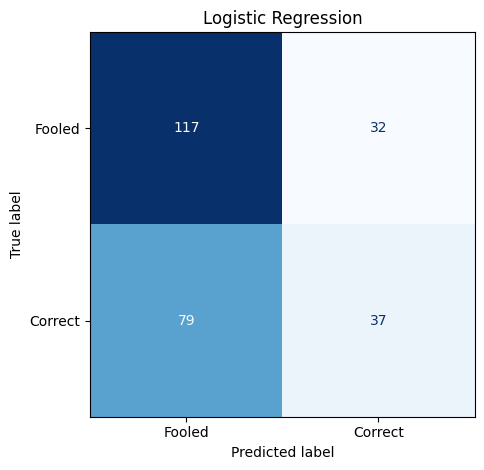

In [70]:
cm = confusion_matrix(y_test, results['Logistic Regression']['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('Logistic Regression')
plt.tight_layout()
plt.show()

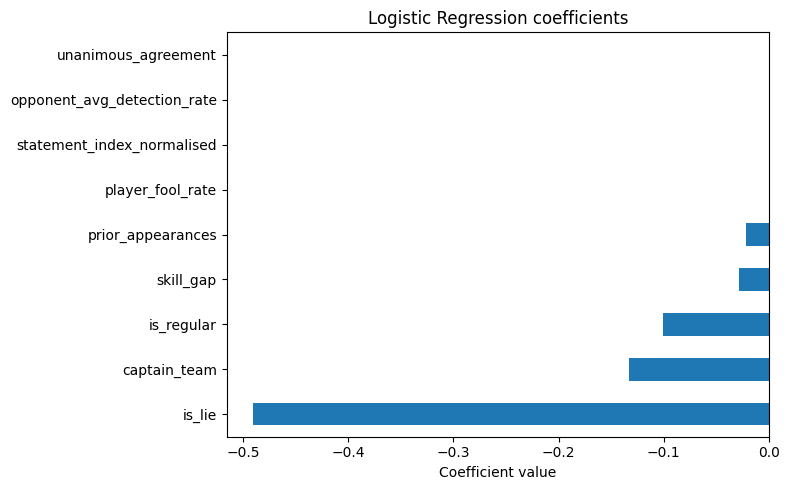

In [72]:
# feature coefficients
coefs = pd.Series(
    logreg_model.coef_[0], index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
coefs.plot(kind='barh', ax=ax)
ax.set_title('Logistic Regression coefficients')
ax.set_xlabel('Coefficient value')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 8.2 SVM (RBF Kernel)

In [73]:
svm_params = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto', 0.01, 0.1],
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf', random_state=SEED, probability=True),
    svm_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print(f"Best params: {svm_grid.best_params_}")
print(f"Best CV ROC-AUC: {svm_grid.best_score_:.4f}\n")

svm_model = evaluate_model(
    'SVM (RBF)', svm_grid.best_estimator_,
    X_train_scaled, X_test_scaled, y_train, y_test
)

Best params: {'C': 10.0, 'gamma': 0.01}
Best CV ROC-AUC: 0.6570

Model: SVM (RBF) 
CV Accuracy:0.6200 (+/- 0.0190)
CV ROC-AUC: 0.6570
CV F1: 0.4167
Test Accuracy:0.6151
Test ROC-AUC: 0.6082
Test F1: 0.5487



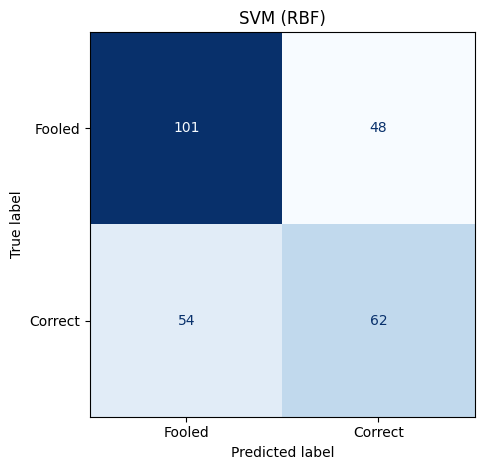

In [75]:
cm = confusion_matrix(y_test, results['SVM (RBF)']['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('SVM (RBF)')
plt.tight_layout()
plt.show()

### 8.3 k-Nearest Neighbours

In [76]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best params: {knn_grid.best_params_}")
print(f"Best CV ROC-AUC: {knn_grid.best_score_:.4f}\n")

knn_model = evaluate_model(
    'KNN', knn_grid.best_estimator_,
    X_train_scaled, X_test_scaled, y_train, y_test
)

Best params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Best CV ROC-AUC: 0.6513

Model: KNN 
CV Accuracy:0.6280 (+/- 0.0504)
CV ROC-AUC: 0.6513
CV F1: 0.4131
Test Accuracy:0.5736
Test ROC-AUC: 0.6013
Test F1: 0.4541



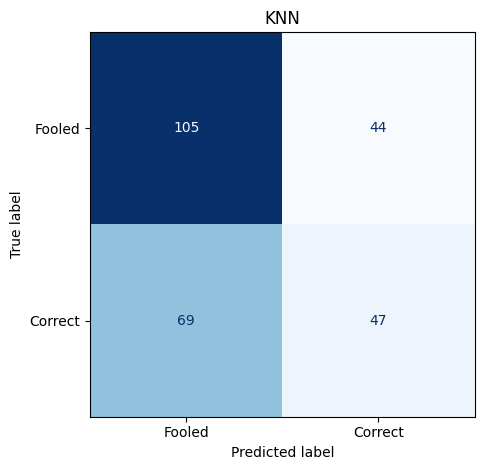

In [80]:
cm = confusion_matrix(y_test, results['KNN']['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('KNN')
plt.tight_layout()
plt.show()

### 8.4 Random Forest

In [ ]:
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    rf_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train, y_train) 
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}\n")
# eval for RF
rf_model = evaluate_model(
    'Random Forest', rf_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)

Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.6741

Model: Random Forest 
CV Accuracy:0.6180 (+/- 0.0445)
CV ROC-AUC: 0.6741
CV F1: 0.2293
Test Accuracy:0.5698
Test ROC-AUC: 0.6345
Test F1: 0.1857



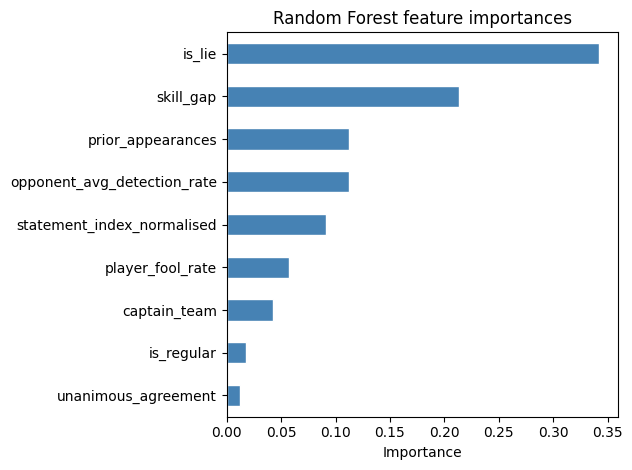

In [79]:
# RF feature importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

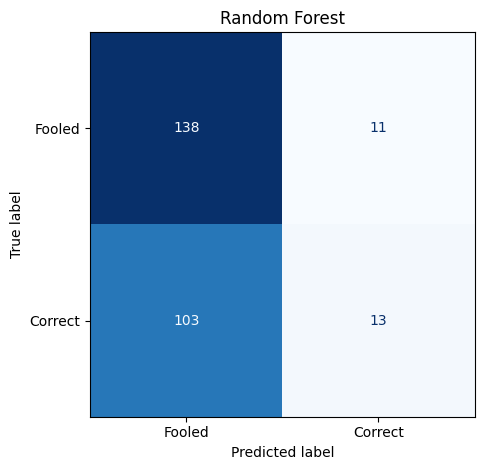

In [81]:
cm = confusion_matrix(y_test, results['Random Forest']['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('Random Forest')
plt.tight_layout()
plt.show()

### 8.5 XGBoost

In [82]:
xgb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 400],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.01, 0.1],
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    xgb_params, cv=cv, scoring='roc_auc', n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train, y_train)

print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV ROC-AUC: {xgb_grid.best_score_:.4f}\n")
# eval for XGBoost
xgb_model = evaluate_model(
    'XGBoost', xgb_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)

Best params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.6}
Best CV ROC-AUC: 0.6733

Model: XGBoost 
CV Accuracy:0.6480 (+/- 0.0673)
CV ROC-AUC: 0.6610
CV F1: 0.4153
Test Accuracy:0.5434
Test ROC-AUC: 0.5947
Test F1: 0.3388



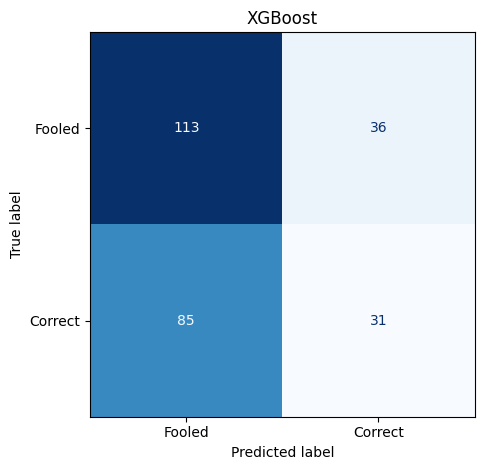

In [83]:
cm = confusion_matrix(y_test, results['XGBoost']['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Fooled', 'Correct']).plot(cmap='Blues', colorbar=False)
plt.title('XGBoost')
plt.tight_layout()
plt.show()

## 9. Classical ML results comparison

In [ ]:
summary = pd.DataFrame({
    name: {
        'CV Accuracy': f"{r['cv_accuracy']:.4f} ± {r['cv_accuracy_std']:.4f}",
        'CV ROC-AUC': f"{r['cv_roc_auc']:.4f}",
        'CV F1': f"{r['cv_f1']:.4f}",
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test ROC-AUC': f"{r['test_roc_auc']:.4f}",
        'Test F1': f"{r['test_f1']:.4f}",
    }
    for name, r in results.items()
}).T

print("Classical models comparison:")
print(summary.to_string())

Classical models comparison:
                         CV Accuracy CV ROC-AUC   CV F1 Test Accuracy Test ROC-AUC Test F1
Logistic Regression  0.6400 ± 0.0443     0.6802  0.4310        0.5811       0.6350  0.4000
SVM (RBF)            0.6200 ± 0.0190     0.6570  0.4167        0.6151       0.6082  0.5487
KNN                  0.6280 ± 0.0504     0.6513  0.4131        0.5736       0.6013  0.4541
Random Forest        0.6180 ± 0.0445     0.6741  0.2293        0.5698       0.6345  0.1857
XGBoost              0.6480 ± 0.0673     0.6610  0.4153        0.5434       0.5947  0.3388


### Plots comparing Test accuracy / ROC-AUC and f1 scores

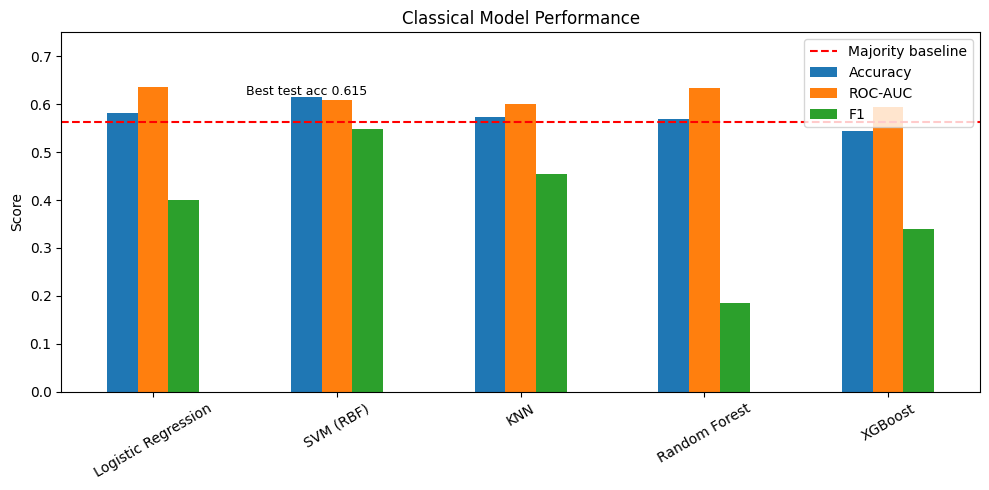

In [93]:
metrics = ['test_accuracy', 'test_roc_auc', 'test_f1']
labels = ['Accuracy', 'ROC-AUC', 'F1']

plot_df = pd.DataFrame(
    {label: [results[name][metric] for name in results] for metric, label in zip(metrics, labels)},
    index=results.keys()
)

ax = plot_df.plot(kind='bar', figsize=(10, 5), rot=30)
ax.axhline(y=max(y_test.value_counts(normalize=True)), color='red', linestyle='--', label='Majority baseline')

# label best test accuracy bar
best = plot_df['Accuracy'].idxmax()
best_val = plot_df['Accuracy'].max()
best_bar = ax.patches[list(results.keys()).index(best)]
ax.text(best_bar.get_x() + best_bar.get_width()/2, best_val + 0.005, f'Best test acc {best_val:.3f}', ha='center', fontsize=9)

plt.title('Classical Model Performance')
plt.ylabel('Score')
plt.ylim(0, 0.75)
plt.legend()
plt.tight_layout()
plt.show()

### ROC curve for classical results

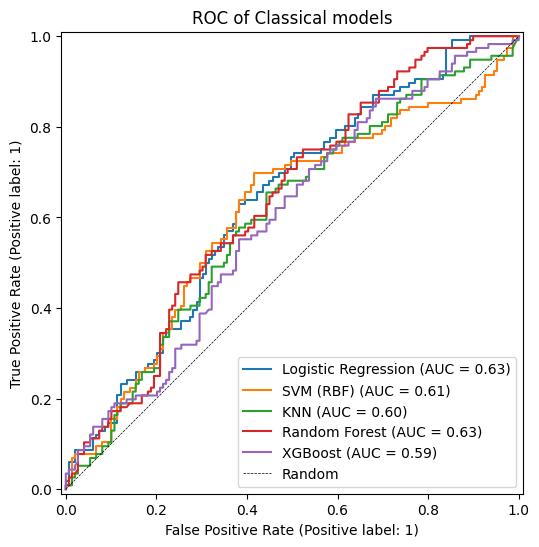

In [88]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    RocCurveDisplay.from_predictions(y_test, r['y_prob'], name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5, label='Random')
ax.set_title('ROC of Classical models')
ax.legend(loc='lower right')
plt.show()

## 10. Feature Importance Analysis

Looking into which of the 9 features have the highest importance/weighting for the classical baselines. This should allow us to choose a subset for the QML section.

In [91]:
# feature importance dataframe
logreg_imp = np.abs(logreg_model.coef_[0])
rf_imp = rf_model.feature_importances_
xgb_imp = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Logistic Regression': logreg_imp / logreg_imp.sum(),
    'Random Forest': rf_imp / rf_imp.sum(),
    'XGBoost': xgb_imp / xgb_imp.sum(),
}, index=features)

importance_df['Mean'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Mean')

print("Mean feature importance ranking:")
print(importance_df['Mean'].sort_values(ascending=False).round(4))

Mean feature importance ranking:
is_lie                         0.4115
skill_gap                      0.1182
captain_team                   0.1016
is_regular                     0.0847
prior_appearances              0.0787
opponent_avg_detection_rate    0.0688
statement_index_normalised     0.0639
player_fool_rate               0.0518
unanimous_agreement            0.0208
Name: Mean, dtype: float64


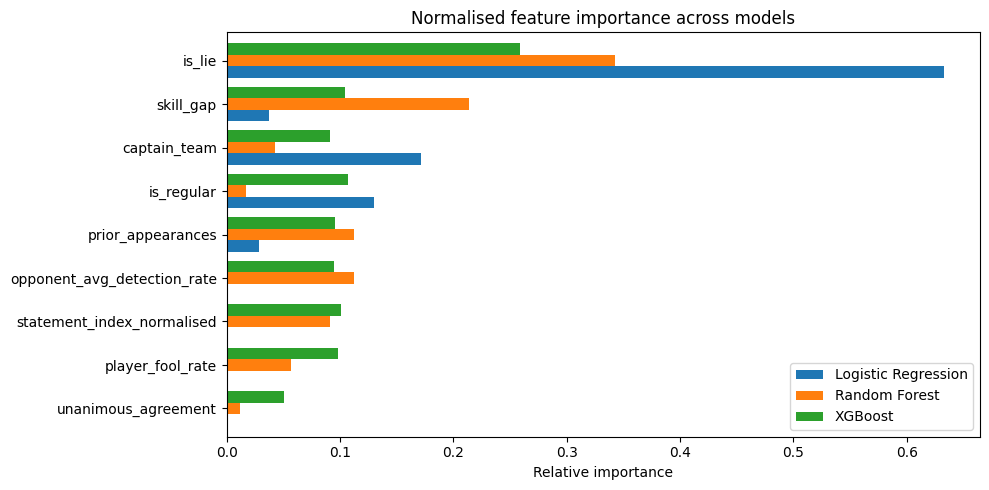

In [90]:
importance_df[['Logistic Regression', 'Random Forest', 'XGBoost']].plot(
    kind='barh', figsize=(10, 5), width=0.8)
plt.title('Normalised feature importance across models')
plt.xlabel('Relative importance')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 10.1 Feature selection for QML (top 5)

In [99]:
top_k = 5  #  5 qubits
qml_features = importance_df['Mean'].sort_values(ascending=False).head(top_k).index.tolist()

print(f"Top features for 5 qubit QC:")
for i, feature in enumerate(qml_features, 1):
    print(f"{feature} (mean: {importance_df.loc[feature, 'Mean']:.4f})")


Top features for 5 qubit QC:
is_lie (mean: 0.4115)
skill_gap (mean: 0.1182)
captain_team (mean: 0.1016)
is_regular (mean: 0.0847)
prior_appearances (mean: 0.0787)


### 10.2  FAMD

We have both continuous and binary features so we will use Prince in order to carry out FAMD and validate the feature importance rankings.

In [106]:
# ordered by importance, highest to lowest
all_features = ['is_lie', 'skill_gap', 'captain_team', 'is_regular', 'prior_appearances',
                'opponent_avg_detection_rate', 'statement_index_normalised', 'player_fool_rate',
                'unanimous_agreement']

In [107]:
famd_df = df[all_features].copy()
for col in ['is_lie', 'is_regular', 'captain_team', 'unanimous_agreement']:
    famd_df[col] = famd_df[col].astype(str).astype('category')

famd = prince.FAMD(n_components=5, random_state=SEED)
famd.fit(famd_df.loc[X_train.index])

contrib = famd.column_contributions_
contrib.columns = [f'Dim {i+1}' for i in range(5)]
contrib.round(3)

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5
variable,,,,,
skill_gap,0.223,0.163,0.014,0.002,0.007
opponent_avg_detection_rate,0.043,0.174,0.002,0.044,0.055
statement_index_normalised,0.072,0.017,0.119,0.040,0.084
player_fool_rate,0.187,0.063,0.013,0.024,0.044
captain_team,0.010,0.024,0.010,0.003,0.040
is_lie,0.013,0.009,0.221,0.028,0.081
is_regular,0.191,0.225,0.036,0.000,0.019
prior_appearances,0.236,0.317,0.488,0.644,0.652
unanimous_agreement,0.023,0.004,0.123,0.216,0.013


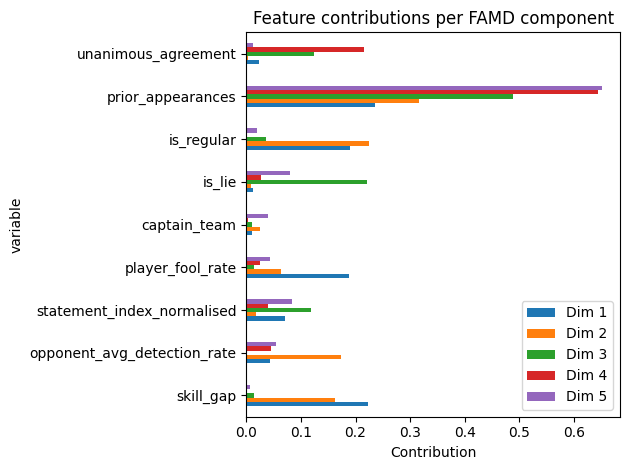

In [109]:
contrib.plot(kind='barh')#, figsize=(10, 5))
plt.title('Feature contributions per FAMD component')
plt.xlabel('Contribution')
plt.tight_layout()
plt.show()

FAMD shows prior_appearances as the dominant source of variance. This only shows that this feature has a wide range rather than any acutal predictive power or importance for our models. It ranked low in the feature importance scores seen above.

### 10.3 Drop features one by one to see if it has any effect

In [ ]:
def run_svm(features):
    svm = SVC(kernel='rbf', C=svm_grid.best_params_['C'], gamma=svm_grid.best_params_['gamma'], random_state=SEED)
    svm.fit(X_train[features], y_train)
    return accuracy_score(y_test, svm.predict(X_test[features]))

remaining = all_features.copy()
rows = []
full_acc = run_svm(remaining)

# drop least important feature each loop
while len(remaining) >= 1:
    acc = run_svm(remaining)
    delta = round(acc - full_acc, 4)
    rows.append({'n_features': len(remaining), 'dropped': remaining[-1] if len(remaining) < len(all_features) else '—', 'accuracy': round(acc, 4), 'delta': delta})
    remaining.pop()

pd.DataFrame(rows).set_index('n_features')

,dropped,accuracy,delta
n_features,,,
9,—,0.5472,0.0000
8,player_fool_rate,0.5623,0.0151
7,statement_index_normalised,0.5623,0.0151
6,opponent_avg_detection_rate,0.5623,0.0151
5,prior_appearances,0.5623,0.0151
4,is_regular,0.5623,0.0151
3,captain_team,0.5585,0.0113
2,skill_gap,0.5623,0.0151
1,is_lie,0.5623,0.0151


## 11. Discussion

All five of the models cluster between 0.54 up to 0.62 test accuracy which is just above the majority baseline of 0.56. SVM (RBF) performs best overall: highest test accuracy (0.615) and F1 (0.549), making it the primary comparison target for the QML phase.

is_lie dominates feature importance (0.41), with skill_gap in second (0.12).
The remaining features which were built unfortunately contribute very little signal.

FAMD identified prior_appearances as the highest variance feature but this is just due to its wide range, not its predictive power/importance. I believe that the feature importance ranking (based on LogReg/RF/XGBoost) is the more reliable point of reference for feature selection for our quantum models.

RF and XGBoost show a drop in cross val to test set which could suggest some overfitting to the training data set. RF has a very low f1 score (0.19) indicating that it mainly predicts the majority class (guesses that the panel are fooled).

The weak overall performance (may be) expected based on the dataset we have access to, as trying to predict human deceptive skills based on just these features alone is limited. Determining if a guest is lying and whether it is obvious, we would likely need to attain the storyline (unstructured data) and the language/facial expressions used.

## 12. Preparation for Quantum models

The top 5 features by mean importance are saved for the QML phase, MinMax scaled to [0, 1] which matches feature map conventions.

**Targets for the QML phase:**
- Majority baseline: 0.562 accuracy
- Best classical model: SVM (RBF) 0.615 accuracy, 0.549 f1

In [110]:
# save preprocessed data for QML phase
qml_data = {
    'features': features,
    'qml_features': qml_features,
    'X_train': X_train,
    'X_test': X_test,
    'X_train_mm': X_train_mm,
    'X_test_mm': X_test_mm,
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler,
    'mm_scaler': mm_scaler,
    'classical_results': {
        name: {k: v for k, v in r.items() if k not in ['model', 'y_pred', 'y_prob']}
        for name, r in results.items()
    }
}

with open('classical_baseline_data_v2.pkl', 'wb') as f:
    pickle.dump(qml_data, f)

print("Preprocessed data saved to classical_baseline_data_v2.pkl")
print(f"QML feature subset: {qml_features}")
print(f"Classical baselines to beat:")
for name, r in results.items():
    print(f"{name}: Acc={r['test_accuracy']:.4f}, AUC={r['test_roc_auc']:.4f}")

Preprocessed data saved to classical_baseline_data_v2.pkl
QML feature subset: ['is_lie', 'skill_gap', 'captain_team', 'is_regular', 'prior_appearances']
Classical baselines to beat:
Logistic Regression: Acc=0.5811, AUC=0.6350
SVM (RBF): Acc=0.6151, AUC=0.6082
KNN: Acc=0.5736, AUC=0.6013
Random Forest: Acc=0.5698, AUC=0.6345
XGBoost: Acc=0.5434, AUC=0.5947


-EOF-